[151.79666459 210.17325841 230.9376083  246.88580251 267.24030154]


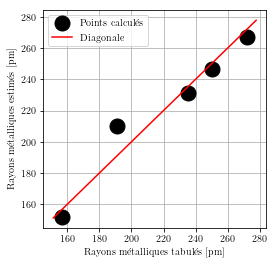

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc

_dpi = 50


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=True)
rc('font', family='serif', size = 10)

Na = 6.0221408 * 10**23  #/mol
rho = np.array([0.535, 0.668, 0.856, 1.532, 1.879]) * 10**3 #g/m3
M = np.array([6.94, 23.0, 39.1, 85.5, 133]) #g/mol


#radius = 1/ (rho / M * Na)**(1/3) * 10**12

radius = np.sqrt(3) / 4 * (2 * M / Na / rho)**(1/3)*10**11

r_met = np.array([157, 191, 235, 250, 272])

fig = plt.figure(figsize=(4,4))
ax = fig.subplots()
ax.plot(r_met, radius, marker = 'o', ls = 'none', markersize = 15, color = 'black', label = 'Points calculés')
xlim= ax.get_xlim()
ax.plot(xlim, xlim, color = 'red', label = "Diagonale")

ax.set_xlabel("Rayons métalliques tabulés [pm]")
ax.set_ylabel("Rayons métalliques estimés [pm]")

ax.grid()
ax.legend()

print(radius)

fig.savefig("Gpy-01.pgf", dpi = _dpi)

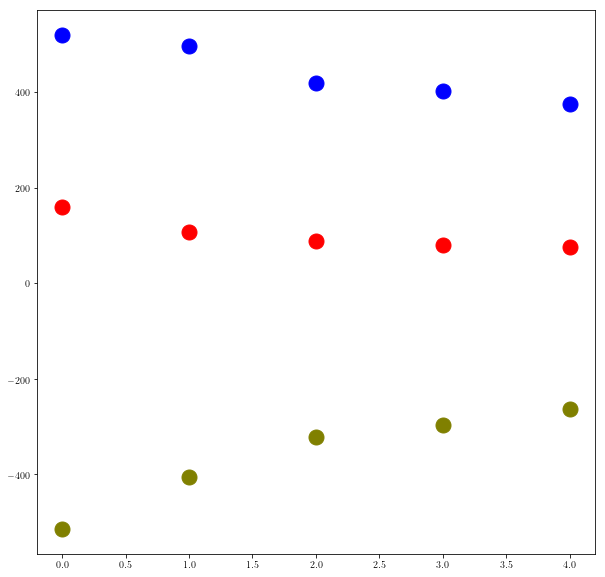

In [69]:
F = 96500

names = ['Li','Na','K', 'Rb', 'Cs']

nb_names = list(range(len(names)))
DhydH = np.array([-123, -96.9, -76.7, -70.8, -62.9]) * 4.184
DsubH = np.array([159, 107, 89, 81, 76])
Ip = np.array([520, 496, 419, 402, 376])
Ec = np.array([-3.045, -2.714, -2.925, -2.925, -2.923])

DelecH = DsubH + Ip + DhydH
DelecG = -F * Ec * 10**(-3)
#L = np.array([670.8, 589.0, 766.5, 794.8])
#chi = np.array([0.98, 0.93, 0.82, 0.82])
#Ip = np.array([5.39, 5.14, 4.34, 4.18])




fig = plt.figure(figsize=(10,10))
ax = fig.subplots()
ax.plot(nb_names, DsubH, marker = 'o', ls = 'none', markersize = 15, color = 'red', label = 'Sublimation')
ax.plot(nb_names, Ip, marker = 'o', ls = 'none', markersize = 15, color = 'blue', label = 'Ionization Pot.')
ax.plot(nb_names, DhydH, marker = 'o', ls = 'none', markersize = 15, color = 'olive', label = 'Hydratation')

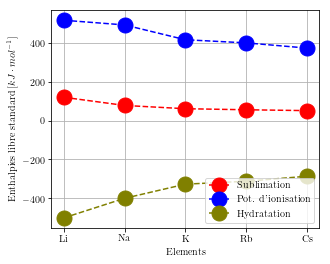

In [192]:
names = ['Li','Na','K', 'Rb', 'Cs']
nb_names = list(range(len(names)))
DhydG = np.array([-502, -401, -328, -313, -287])
DsubG = np.array([120.083, 77.852, 60.99, 55.604, 51.124])
Ip = np.array([517.11,492.92,416.56,400.39,373.52])


DrG = DsubG + Ip + DhydG

fig = plt.figure(figsize=(4.8,4))
ax = fig.subplots()
ax.plot(nb_names, DsubG, marker = 'o', markersize = 15, ls = 'dashed', color = 'red', label = 'Sublimation')
ax.plot(nb_names, Ip, marker = 'o', markersize = 15, ls = 'dashed', color = 'blue', label = "Pot. d'ionisation")
ax.plot(nb_names, DhydG, marker = 'o', markersize = 15, ls = 'dashed', color = 'olive', label = 'Hydratation')

ax.set_xticks(nb_names)
ax.set_xticklabels(names)
ax.grid()

ax.set_xlabel("Elements")
ax.set_ylabel("Enthalpies libre standard [$kJ \cdot mol^{-1}$]")

ax.legend()

fig.savefig("Gpy-02.pgf", dpi = _dpi)

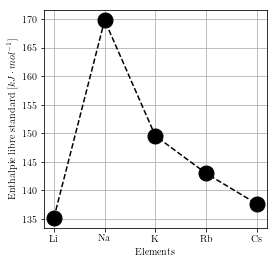

In [180]:
fig = plt.figure(figsize=(4,4))
ax = fig.subplots()
ax.plot(nb_names, DrG, marker = 'o', markersize = 15, ls = 'dashed', color = 'black')

ax.set_xticks(nb_names)
ax.set_xticklabels(names)
ax.grid()

ax.set_xlabel("Elements")
ax.set_ylabel("Enthalpie libre standard [$kJ \cdot mol^{-1}$]")

fig.savefig("Gpy-03.pgf", dpi = _dpi)

'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with 'x' & 'y'.  Please use a 2-D array with a single row if you really want to specify the same RGB or RGBA value for all points.
'c' argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches

 
0.009727 x - 4.366 1.0364305332435094e-05


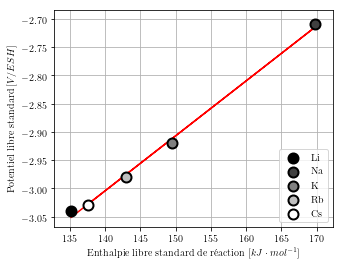

In [193]:
Ec = np.array([-3.04, -2.71, -2.92, -2.98, -3.03])

map_matplotlib = colormap(len(names), name = 'gray')

P = np.poly1d(np.polyfit(DrG, Ec, deg = 1))

fig = plt.figure(figsize=(5,4))
ax = fig.subplots()
ax.plot(DrG, P(DrG), color='red')
#ax.scatter(DrG, Ec,100, marker = 'o',  c = map_matplotlib, linewidths = 2, edgecolors ='black', Zorder = 3) 
#, markersize = 15, edgecolors =)#markersize = 15, 
ax.grid()

for n in range(len(names)) : 
    ax.scatter(DrG[n],Ec[n], 100, c = map_matplotlib[n], label = names[n], 
               linewidths = 2, edgecolors ='black', Zorder = 3)

ax.set_xlabel("Enthalpie libre standard de réaction [$kJ \cdot mol^{-1}$]")
ax.set_ylabel("Potentiel libre standard [$V/ESH$]")
ax.legend(loc = 'lower right')
#fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=True, shadow=True, ncol=5)

print(P, 1/96485)

fig.savefig("Gpy-04.pgf", dpi = _dpi)